In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers, applications, mixed_precision
import matplotlib.pyplot as plt
import numpy as np
import os


policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision enabled:", policy.compute_dtype)


BATCH_SIZE = 8  
IMAGE_SIZE = 300 # EfficientNetB3 standard resolution
CHANNELS = 3

print(f"Configuration: Batch Size={BATCH_SIZE}, Image Size={IMAGE_SIZE}")

2025-12-11 13:32:35.885059: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Mixed precision enabled: float16
Configuration: Batch Size=8, Image Size=300


In [2]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "training/Diseases",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),z
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print("Classes:", class_names)

# Split Dataset (70% Train, 20% Val, 10% Test)
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = int(0.1 * len(dataset))

train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size).take(val_size)
test_ds = dataset.skip(train_size).skip(val_size)

# Performance Tuning (Prefetching is vital for Ryzen CPUs)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3596 files belonging to 3 classes.


I0000 00:00:1765459991.033454     998 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Classes: ['benign', 'melanoma', 'non_melanoma_cancer']


In [3]:
def get_dataset_partitions_tf(ds,train_split=0.7,val_split=0.15,test_split=0.1,shuffle=True , shuffle_size = 10000):
        ds_size  = len(ds)
        if shuffle:
            ds = ds.shuffle(shuffle_size, seed=12)
            
        train_size = int(train_split *ds_size)
        val_size = int(val_split * ds_size)
    
        train_ds = ds.take(train_size)
    
        val_ds=ds.skip(train_size).take(val_size)
        test_ds = ds.skip(train_size).skip(val_size)
    
        return train_ds,val_ds,test_ds

In [4]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [5]:
def sparse_categorical_focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.reshape(y_pred, [-1, y_pred.shape[-1]])
        idx = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
        probs = tf.gather_nd(y_pred, idx)
        focal_modulation = tf.pow(1.0 - probs, gamma)
        loss = -alpha * focal_modulation * tf.math.log(probs + 1e-7)
        return tf.reduce_mean(loss)
    return focal_loss_fixed

# Weights: Benign=1.0, Melanoma=3.0, Non-Melanoma=1.0
class_weights_dict = {0: 1.0, 1: 3.0, 2: 1.0}

In [6]:
# 1. Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# 2. Base Model (EfficientNetB3)
base_model = applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)
base_model.trainable = False 

# 3. Build Model with Float32 Output
inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False) 
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# CRITICAL: Force dtype='float32' for the final classification layer
# otherwise the model will output NaNs in Mixed Precision
outputs = layers.Dense(3, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         4,611 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,794,290 (41.18 MB)

 Trainable params: 7,683 (30.01 KB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=sparse_categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

print("Phase 1: Training Top Layers...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    class_weight=class_weights_dict
)

Phase 1: Training Top Layers...
Epoch 1/10


2025-12-11 13:34:33.137288: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 356 of 10000
2025-12-11 13:34:27.231568: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-12-11 13:34:28.397590: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500


315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4539 - loss: 0.3961

2025-12-11 13:35:22.641613: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640256 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


315/315 ━━━━━━━━━━━━━━━━━━━━ 86s 161ms/step - accuracy: 0.5016 - loss: 0.3427 - val_accuracy: 0.6437 - val_loss: 0.1062
Epoch 2/10


...

287/315 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.6155 - loss: 0.2006

2025-12-11 13:41:12.096885: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640256 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


315/315 ━━━━━━━━━━━━━━━━━━━━ 43s 130ms/step - accuracy: 0.6179 - loss: 0.2019 - val_accuracy: 0.6805 - val_loss: 0.1042
Epoch 10/10
301/315 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.6141 - loss: 0.1945

2025-12-11 13:41:55.981928: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640256 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


315/315 ━━━━━━━━━━━━━━━━━━━━ 44s 131ms/step - accuracy: 0.6004 - loss: 0.1973 - val_accuracy: 0.5695 - val_loss: 0.1379


In [8]:
base_model.trainable = True

# Unfreeze last 50 layers
N = 50
for layer in base_model.layers[:-N]:
    layer.trainable = False

# Recompile with LOW LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=sparse_categorical_focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    patience=8, restore_best_weights=True, monitor='val_loss'
)

print("Phase 2: Fine-Tuning...")
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Phase 2: Fine-Tuning...
Epoch 1/40


2025-12-11 13:43:27.683470: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640288 bytes after encountering the first element of size 8640288 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


315/315 ━━━━━━━━━━━━━━━━━━━━ 116s 234ms/step - accuracy: 0.5600 - loss: 0.2286 - val_accuracy: 0.6194 - val_loss: 0.1304
Epoch 2/40


2025-12-11 13:44:54.385883: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640288 bytes after encountering the first element of size 8640288 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.6014 - loss: 0.2033

...

315/315 ━━━━━━━━━━━━━━━━━━━━ 66s 202ms/step - accuracy: 0.7226 - loss: 0.1138 - val_accuracy: 0.7948 - val_loss: 0.0483
Epoch 40/40


2025-12-11 14:26:43.250828: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640288 bytes after encountering the first element of size 8640288 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


310/315 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7488 - loss: 0.1052

2025-12-11 14:27:40.998718: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640256 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


315/315 ━━━━━━━━━━━━━━━━━━━━ 66s 200ms/step - accuracy: 0.7353 - loss: 0.1083 - val_accuracy: 0.7743 - val_loss: 0.0547


In [10]:
model.evaluate(test_ds)

2025-12-11 14:35:14.332404: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640256 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.7739 - loss: 0.0609 


[0.060947928577661514, 0.7738970518112183]

In [11]:
model.save("EffitientNetB3Test5.keras")

2025-12-11 15:18:23.821481: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640256 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-12-11 15:19:07.486983: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



--- Classification Report ---
                     precision    recall  f1-score   support

             benign       0.84      0.76      0.80       237
           melanoma       0.62      0.86      0.72       176
non_melanoma_cancer       0.92      0.60      0.72       131

           accuracy                           0.75       544
          macro avg       0.79      0.74      0.75       544
       weighted avg       0.79      0.75      0.76       544



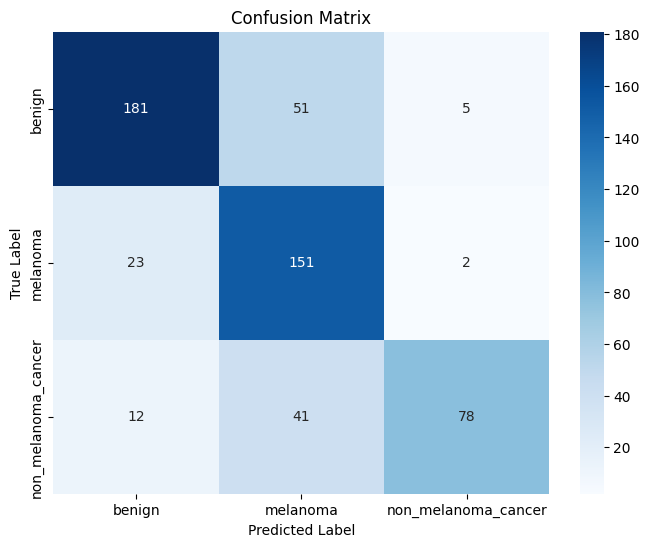

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Corrected Evaluation on Test Data ---

y_true_list = []
y_pred_probs_list = []

print("Collecting true labels and generating predictions simultaneously...")

# Iterate through the test dataset once to ensure consistency
for images, labels in test_ds:
    # 1. Collect True Labels
    # Note: tf.data.Dataset labels are usually float or int, convert to numpy
    y_true_list.append(labels.numpy()) 
    
    # 2. Generate Predictions (Probabilities)
    # model(images) is equivalent to model.predict(images)
    predictions = model(images, training=False).numpy()
    y_pred_probs_list.append(predictions)

# Concatenate all batches into single arrays
y_true = np.concatenate(y_true_list, axis=0)
y_pred_probs = np.concatenate(y_pred_probs_list, axis=0)

# Convert predicted probabilities to class indices (the final prediction)
y_pred = np.argmax(y_pred_probs, axis=1)

# Ensure y_true is flat (if your labels are sparse, which they should be)
if y_true.ndim > 1:
    y_true = np.squeeze(y_true)


# 3. Print Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [14]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import classification_report

def tta_predict(model, dataset, n_augmentations=5):
    # Create an augmentation layer specifically for inference
    aug_layer = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.1),
    ])

    print(f"Starting TTA ({n_augmentations} passes)...")
    
    # Storage for accumulated probabilities
    summed_probs = []
    labels_list = []
    
    # We need to iterate carefully to keep order
    for images, labels in dataset:
        labels_list.append(labels.numpy())
        
        # Pass 1: Original Images
        batch_probs = model(images, training=False)
        
        # Pass 2 to N: Augmented Images
        for _ in range(n_augmentations - 1):
            augmented_images = aug_layer(images, training=True)
            batch_probs += model(augmented_images, training=False)
            
        # Average the predictions
        avg_probs = batch_probs / n_augmentations
        summed_probs.append(avg_probs)
        
    y_true = np.concatenate(labels_list, axis=0)
    y_pred_probs = np.concatenate(summed_probs, axis=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    return y_true, y_pred

# Run TTA
y_true, y_pred_tta = tta_predict(model, test_ds)
print(classification_report(y_true, y_pred_tta, target_names=class_names))

Starting TTA (5 passes)...


2025-12-11 15:24:43.383664: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8640256 bytes after encountering the first element of size 8640256 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


                     precision    recall  f1-score   support

             benign       0.89      0.89      0.89       229
           melanoma       0.85      0.86      0.86       151
non_melanoma_cancer       0.94      0.94      0.94       164

           accuracy                           0.90       544
          macro avg       0.89      0.90      0.90       544
       weighted avg       0.90      0.90      0.90       544



In [15]:
# Save the entire model (architecture + weights)
model.save("melanoma_efficientnet_b3_90acc.keras")
print("Model saved successfully.")

Model saved successfully.


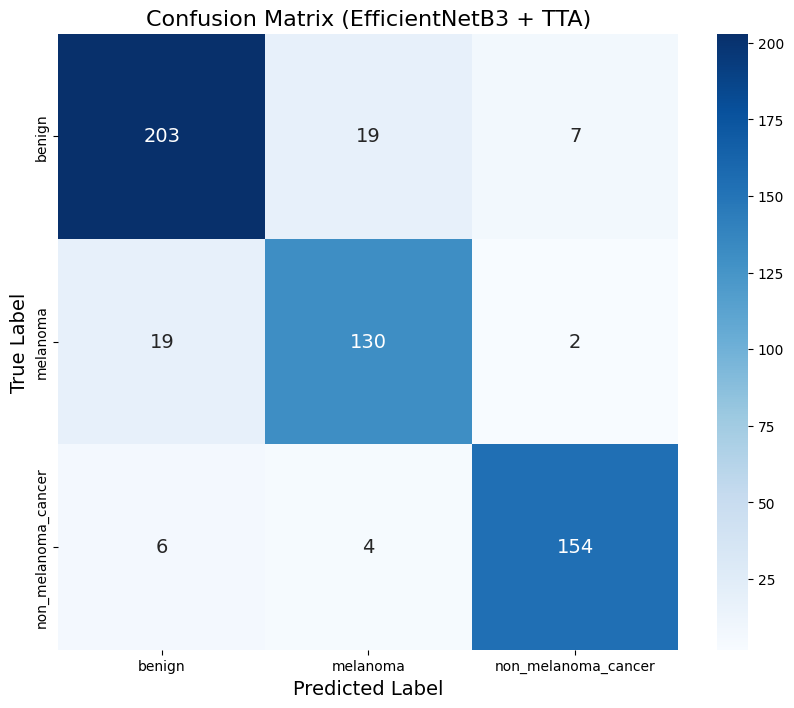

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Calculate the Confusion Matrix
# Note: Ensure 'y_pred' is your final prediction array (e.g., y_pred_tta)
cm = confusion_matrix(y_true, y_pred_tta) 

# 2. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',       # 'd' means integer formatting (no decimals)
    cmap='Blues',  # Color scheme
    xticklabels=class_names, 
    yticklabels=class_names,
    annot_kws={"size": 14} # Larger font size for numbers
)

plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix (EfficientNetB3 + TTA)', fontsize=16)
plt.show()

Selecting 9 sample images...
Running TTA (5 passes) on samples...


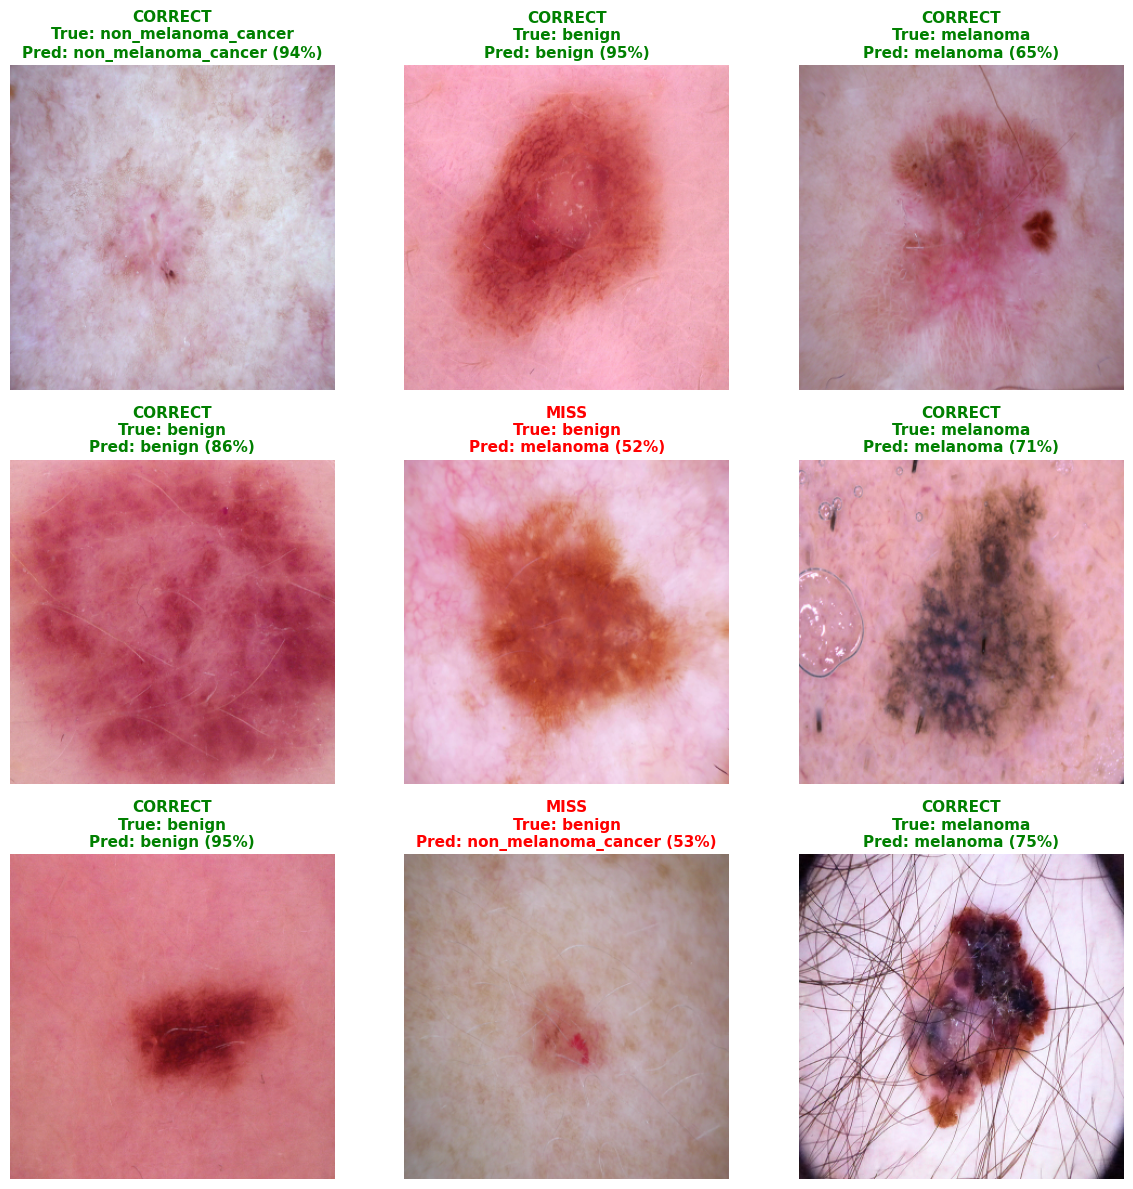

In [21]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def visualize_tta_predictions(model, dataset, class_names):
    plt.figure(figsize=(12, 12))
    
    # 1. Get exactly 9 images
    # We unbatch and rebatch to 9 to ensure we have the perfect amount for a 3x3 grid
    print("Selecting 9 sample images...")
    sample_batch = dataset.unbatch().batch(9).take(1)
    images, labels = next(iter(sample_batch))
    
    # 2. Define TTA Augmentation Layer (Same as before)
    aug_layer = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.1),
    ])
    
    # 3. Perform TTA (Voting)
    print("Running TTA (5 passes) on samples...")
    # Initialize probabilities with zeros
    summed_probs = np.zeros((9, len(class_names)))
    
    # Pass 1: Original Images
    summed_probs += model.predict(images, verbose=0)
    
    # Pass 2-5: Augmented Images
    for i in range(4):
        aug_images = aug_layer(images, training=True)
        summed_probs += model.predict(aug_images, verbose=0)
        
    # Average the predictions
    avg_probs = summed_probs / 5.0
    pred_indices = np.argmax(avg_probs, axis=1)
    
    # 4. Plotting the 3x3 Grid
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # Convert image to uint8 for display (assuming range 0-255)
        img_display = images[i].numpy().astype("uint8")
        plt.imshow(img_display)
        
        # Get labels and confidence
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_indices[i]]
        confidence = np.max(avg_probs[i]) * 100
        
        # Color logic: Green = Correct, Red = Wrong
        if true_label == pred_label:
            color = 'green'
            title_text = f"CORRECT\nTrue: {true_label}\nPred: {pred_label} ({confidence:.0f}%)"
        else:
            color = 'red'
            title_text = f"MISS\nTrue: {true_label}\nPred: {pred_label} ({confidence:.0f}%)"
            
        plt.title(title_text, color=color, fontsize=11, fontweight='bold')
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_tta_predictions(model, test_ds, class_names)

In [22]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

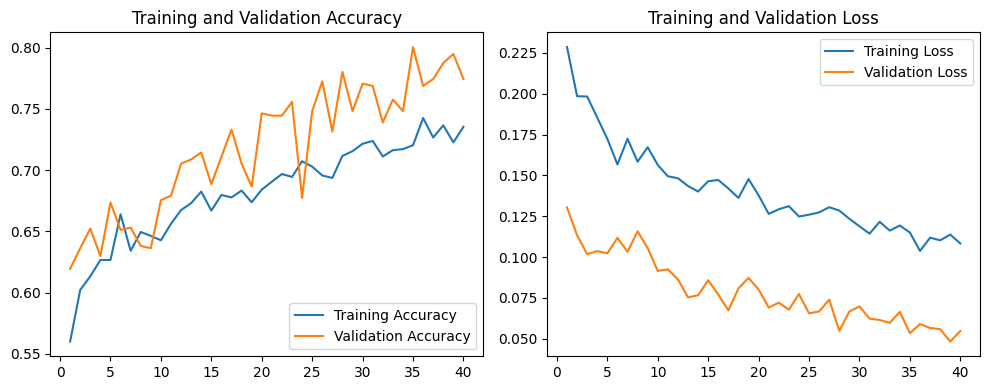

In [23]:
epochs_ran = len(acc)  # number of completed epochs

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(range(1, epochs_ran + 1), acc, label='Training Accuracy')
plt.plot(range(1, epochs_ran + 1), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(1, epochs_ran + 1), loss, label='Training Loss')
plt.plot(range(1, epochs_ran + 1), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()